# Planewave simulation

This notebook takes you through a simple planewave simulation for the same crystal used in the thesis and creates a RGB overlay to compare the differences.
Feel free to play around with the simulation parameters like the electron energy.
```{warning}
**Caution!**
This simulation requires some processing power to work and is therefore not suitable to run here in the browser. 
If you want to test out this notebook it is recommended to download the notebook and run it locally instead.
There is also the multislice_fast notebook which runs perfectly fine in the browser.

In [1]:
import abtem
import ase
import matplotlib.pyplot as plt
import numpy as np

# Creating the crystal

In [2]:
STO_crystal = ase.Atoms(
    "SrTiO3",
    scaled_positions=[
        (0.0, 0.0, 0.0),

        (0.5, 0.5, 0.5),

        (0.5, 0.0, 0.5),
        (0.5, 0.5, 0.0),
        (0.0, 0.5, 0.5),
    ],
    cell=[3.91270131, 3.91270131, 3.91270131, 90, 90, 90],
    pbc=True
)
STO_orthorhombic = abtem.orthogonalize_cell(STO_crystal)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='y [Å]', ylabel='z [Å]'>)

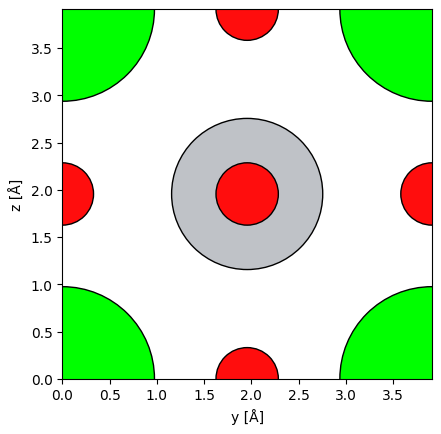

In [3]:
fig,ax = plt.subplots()
abtem.show_atoms(STO_orthorhombic,plane='yz',scale=0.5,tight_limits=True,show_periodic=True,ax=ax)

# Creating the crystal potential

In [4]:
sampling = 0.1 #Angstrom
slice_thickness = 0.5 #Angstrom
thickness = 48 #unit cells 
sample_size = (1,1,thickness)
energy = 20e3 #eV

In [5]:
unit_cell_potential = abtem.Potential(
            STO_orthorhombic,
            sampling=sampling,
            parametrization="lobato",
            slice_thickness=slice_thickness,
            projection="finite",
        )

potential = abtem.CrystalPotential(
    unit_cell_potential,
    repetitions=sample_size,
)

# Creating the planewave 

In [6]:
planewave = abtem.PlaneWave(energy=energy).match_grid(potential)

# Running the simulation

In [7]:
from abtem.multislice import RealSpaceMultislice 

detector = abtem.PixelatedDetector(max_angle=None)

CMS = RealSpaceMultislice()
PCMS = RealSpaceMultislice(
    order = 3,
)
FCMS = RealSpaceMultislice(
    order = 3,
    expansion_scope='full'
)

## CMS

In [8]:
exitwave_cms = planewave.multislice(
    potential=potential,
    detectors=detector,
    algorithm = CMS,
    pbar=True,
    lazy=False
    )

multislice:   0%|          | 0/384 [00:00<?, ?it/s]

In [9]:
exitwave_pcms = planewave.multislice(
    potential=potential,
    detectors=detector,
    algorithm = PCMS,
    pbar=True,
    lazy=False
    )

multislice:   0%|          | 0/384 [00:00<?, ?it/s]

In [10]:
exitwave_fcms = planewave.multislice(
    potential=potential,
    detectors=detector,
    algorithm = FCMS,
    pbar=True,
    lazy=False
    )

multislice:   0%|          | 0/384 [00:00<?, ?it/s]

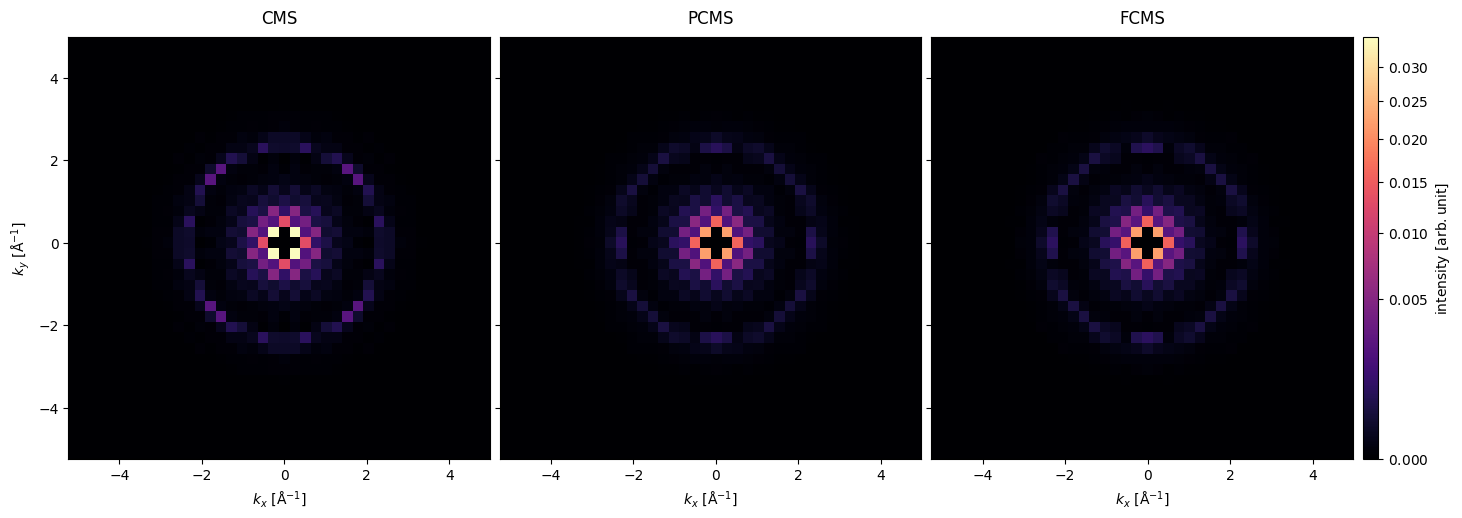

In [11]:
all_exitwaves = abtem.stack(
    (
        exitwave_cms.block_direct(),
        exitwave_pcms.block_direct(),
        exitwave_fcms.block_direct()
    ),
    (
        'CMS',
        'PCMS',
        'FCMS'
    )
)

all_exitwaves.show(
    explode = True,
    cbar=True,
    cmap='magma',
    figsize=(16, 9),
    vmin=0,
    common_color_scale=True,
    power=0.5
)

# RGB overlay

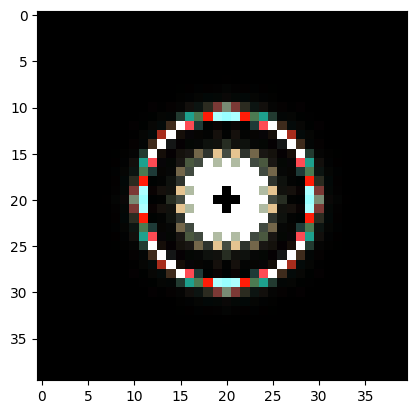

In [12]:
threshold = 0.95

cms_array = exitwave_cms.block_direct().array
R_quantile = np.quantile(cms_array, threshold)
cms_array = np.clip(cms_array, 0, R_quantile)
R = cms_array / cms_array.max()

pcms_array = exitwave_pcms.block_direct().array
G_quantile = np.quantile(pcms_array, threshold)
pcms_array = np.clip(pcms_array, 0, G_quantile)
G = pcms_array / pcms_array.max()

fcms_array = exitwave_fcms.block_direct().array
B_quantile = np.quantile(fcms_array, threshold)
fcms_array = np.clip(fcms_array, 0, B_quantile)
B = fcms_array / fcms_array.max()

rgb_image = np.stack([R, G, B], axis=-1)
plt.imshow(rgb_image, vmin=0)
